# [Ethereum Fraud Detection]

**Student:** [Jonathan "Jangle" Angle]  
**Course:** AI001  
**Date:** [20/06/2025]

## Problem Statement
[Tabular Classification]

## Dataset
- **Source:** [Ethereum Fraud Detection: https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset/data]
- **Size:** [9,840]
- **Domain:** [Tabular]

## Objectives
- To build, train, and evaluate multiple machine learning models (including Logistic Regression, SVM, and Random Forest) to classify Ethereum accounts as fraudulent or legitimate.
- To identify the best-performing model based on accuracy, precision, and recall, and analyze its feature importance to understand the primary indicators of fraudulent activity.

In [3]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import re

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Load the dataset from the CSV file into a pandas DataFrame
try:
    file_path = '../data/transaction_dataset.csv'
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully from: {file_path}")
except FileNotFoundError:
    print(f"Error: Could not find the file at the specified path.")
    print("Please ensure the relative path is correct.")
# Check if the DataFrame exists
if 'df' in locals():
    # Rename the 'FLAG' column to 'is_fraud'
    df.rename(columns={'FLAG': 'is_fraud'}, inplace=True)

# Define the function to clean column names
def clean_col_names(df):
    """Cleans column names of a pandas DataFrame."""
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.strip()  # Remove whitespace
        new_col = new_col.lower() # Convert to lowercase
        new_col = re.sub(r'[\s\.\(\)-]+', '_', new_col) # Replace spaces and special chars with _
        new_col = re.sub(r'_$', '', new_col) # Remove trailing underscore
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Check if the DataFrame 'df' exists
if 'df' in locals():
    # Apply the function 
    df = clean_col_names(df)    
else:
    print("DataFrame 'df' not found.")

Dataset loaded successfully from: ../data/transaction_dataset.csv


In [8]:
# Basic dataset information
print("\n--- Dataset Info ---")
df.info()
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Target distribution:\n{df['is_fraud'].value_counts()}")


# Statistical summary
df.describe()

print("--- First 5 Rows of the Dataset ---")
display(df.head())



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   unnamed:_0                                           9841 non-null   int64  
 1   index                                                9841 non-null   int64  
 2   address                                              9841 non-null   object 
 3   is_fraud                                             9841 non-null   int64  
 4   avg_min_between_sent_tnx                             9841 non-null   float64
 5   avg_min_between_received_tnx                         9841 non-null   float64
 6   time_diff_between_first_and_last_mins                9841 non-null   float64
 7   sent_tnx                                             9841 non-null   int64  
 8   received_tnx                                  

,unnamed:_0,index,address,is_fraud,avg_min_between_sent_tnx,avg_min_between_received_tnx,time_diff_between_first_and_last_mins,sent_tnx,received_tnx,number_of_created_contracts,unique_received_from_addresses,unique_sent_to_addresses,min_value_received,max_value_received,avg_val_received,min_val_sent,max_val_sent,avg_val_sent,min_value_sent_to_contract,max_val_sent_to_contract,avg_value_sent_to_contract,total_transactions_including_tnx_to_create_contract,total_ether_sent,total_ether_received,total_ether_sent_contracts,total_ether_balance,total_erc20_tnxs,erc20_total_ether_received,erc20_total_ether_sent,erc20_total_ether_sent_contract,erc20_uniq_sent_addr,erc20_uniq_rec_addr,erc20_uniq_sent_addr_1,erc20_uniq_rec_contract_addr,erc20_avg_time_between_sent_tnx,erc20_avg_time_between_rec_tnx,erc20_avg_time_between_rec_2_tnx,erc20_avg_time_between_contract_tnx,erc20_min_val_rec,erc20_max_val_rec,erc20_avg_val_rec,erc20_min_val_sent,erc20_max_val_sent,erc20_avg_val_sent,erc20_min_val_sent_contract,erc20_max_val_sent_contract,erc20_avg_val_sent_contract,erc20_uniq_sent_token_name,erc20_uniq_rec_token_name,erc20_most_sent_token_type,erc20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.00,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.00,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.05,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.00,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.00,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [ ]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Target distribution
df['is_fraud'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Target Distribution')
axes[0,0].set_xlabel('Fraud Status')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['Not Fraud', 'Fraud'], rotation=0) 


# Feature correlations
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', ax=axes[0,1]) # Removed annot=True for better readability with many features
axes[0,1].set_title('Feature Correlations')

# Select numeric features for distribution and box plots
features_to_visualize = ['total_erc20_tnxs', 'avg_min_between_sent_tnx', 'max_val_sent', 'sent_tnx']

# Feature distributions
df[features_to_visualize].hist(bins=20, ax=axes[1,0], alpha=0.7)
axes[1,0].set_title('Feature Distributions (Selected)')

if features_to_visualize:
    # Calculate the upper limit based on a high percentile across the selected features
    combined_upper_limit = df[features_to_visualize].quantile(0.95).max()
    axes[1,0].set_xlim(0, combined_upper_limit)

# Box plot
df.boxplot(column=features_to_visualize, ax=axes[1,1])
axes[1,1].set_title('Box Plot (Selected Features)')
axes[1,1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

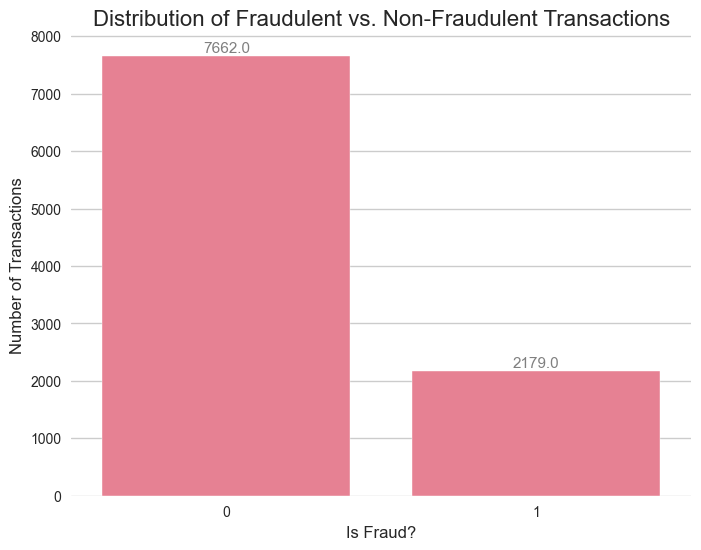

In [11]:
plt.figure(figsize=(8, 6))

# Create a count plot of the 'is_fraud' column
# This will show us the number of fraudulent vs. non-fraudulent transactions
ax = sns.countplot(x='is_fraud', data=df)

# Add a title and labels for clarity
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions', fontsize=16)
plt.xlabel('Is Fraud?', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Annotate the bars with the exact counts
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='gray', xytext=(0, 5),
                textcoords='offset points')

plt.show()

For a classification problem like this, the most important first visualization is to see the distribution of the target variable ('is_fraud'). We need to know how many fraudulent transactions there are compared to legitimate ones. This can tell us if our dataset is "imbalanced".

In [22]:
# Prepare features and target
# First, identify all non-numeric columns that we need to exclude from scaling.
# From your df.info(), these are 'object' type columns.
cols_to_drop = ['is_fraud', 'address', 'erc20_most_sent_token_type', 'erc20_most_rec_token_type']

# We also drop unnamed and index columns as they are not useful features.
cols_to_drop.extend(['unnamed:_0', 'index'])

X = df.drop(columns=cols_to_drop)
y = df['is_fraud']

# The ERC20 columns have missing values (NaNs). For this stage, we'll fill them with 0.
# A more advanced step could be to use a more sophisticated imputation method.
X.fillna(0, inplace=True)

# Split the data (this part was correct)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Scale features
# Now the scaler will only see numeric data and will work correctly.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print("\\nFeatures successfully scaled!")

Training set shape: (5904, 45)
Validation set shape: (1968, 45)
Test set shape: (1969, 45)
\nFeatures successfully scaled!


# 3. Model Implementation

Let's implement and train multiple models for comparison.

In [ ]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42)
}

# Train models and store results
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    train_pred = model.predict(X_train_scaled)
    val_pred = model.predict(X_val_scaled)
    
    # Store results
    results[name] = {
        'model': model,
        'train_accuracy': accuracy_score(y_train, train_pred),
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_predictions': val_pred
    }
    
    print(f"Train Accuracy: {results[name]['train_accuracy']:.4f}")
    print(f"Validation Accuracy: {results[name]['val_accuracy']:.4f}")


Training Logistic Regression...
Train Accuracy: 0.7810
Validation Accuracy: 0.7805

Training Random Forest...
Train Accuracy: 1.0000
Validation Accuracy: 0.9492

Training SVM...
Train Accuracy: 0.7847
Validation Accuracy: 0.7810


# 4. Results and Analysis

Let's analyze and compare the performance of our models.

Model Comparison:
                 Model  Train Accuracy  Validation Accuracy
0  Logistic Regression        0.780996             0.780488
1        Random Forest        1.000000             0.949187
2                  SVM        0.784722             0.780996


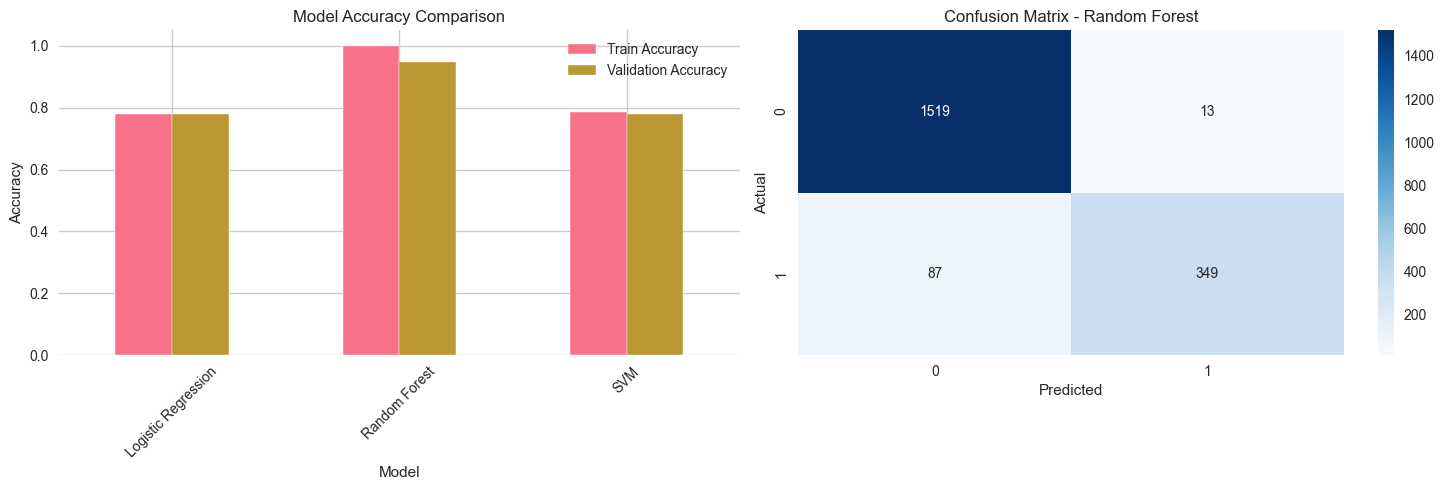


Best Model: Random Forest
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1532
           1       0.96      0.80      0.87       436

    accuracy                           0.95      1968
   macro avg       0.95      0.90      0.92      1968
weighted avg       0.95      0.95      0.95      1968



In [16]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[model]['train_accuracy'] for model in results.keys()],
    'Validation Accuracy': [results[model]['val_accuracy'] for model in results.keys()]
})

print("Model Comparison:")
print(comparison_df)

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy comparison
comparison_df.set_index('Model')[['Train Accuracy', 'Validation Accuracy']].plot(
    kind='bar', ax=ax1, title='Model Accuracy Comparison'
)
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_xticklabels(comparison_df['Model'], rotation=45)

# Best model confusion matrix
best_model_name = comparison_df.loc[comparison_df['Validation Accuracy'].idxmax(), 'Model']
best_predictions = results[best_model_name]['val_predictions']

cm = confusion_matrix(y_val, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title(f'Confusion Matrix - {best_model_name}')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"\nBest Model: {best_model_name}")
print(f"Classification Report for {best_model_name}:")
print(classification_report(y_val, best_predictions))

In [17]:
# Test the best model on test set
best_model = results[best_model_name]['model']
test_predictions = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Final Test Accuracy ({best_model_name}): {test_accuracy:.4f}")
print("\nFinal Test Classification Report:")
print(classification_report(y_test, test_predictions))

Final Test Accuracy (Random Forest): 0.9568

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1533
           1       0.98      0.83      0.89       436

    accuracy                           0.96      1969
   macro avg       0.96      0.91      0.93      1969
weighted avg       0.96      0.96      0.96      1969



/var/folders/2j/7mvkcjts14j38kfhm5tdm96r0000gn/T/ipykernel_9046/832098760.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


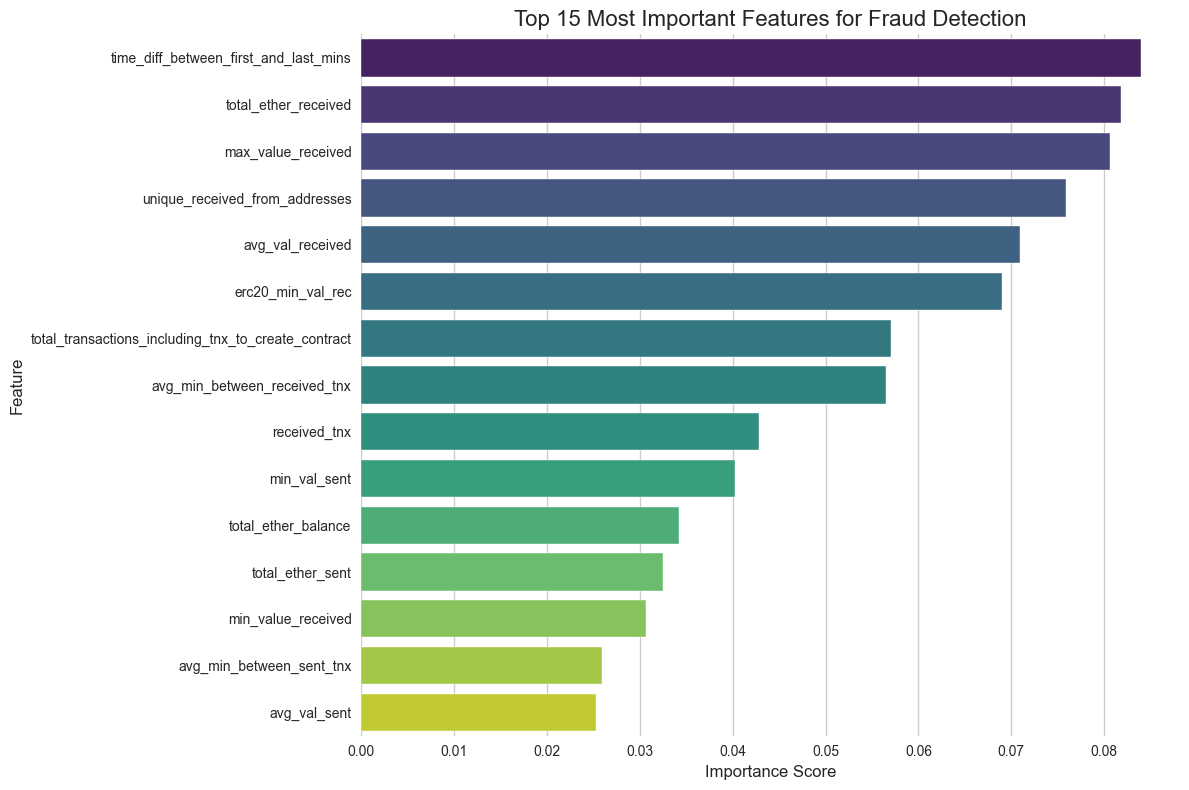

In [18]:
# --- Feature Importance Visualization ---

# Get feature importances from the best model
# 'results' is the dictionary where you stored your trained models
best_model = results['Random Forest']['model']
importances = best_model.feature_importances_
feature_names = X.columns # X is your features DataFrame before scaling

# Create a DataFrame for easier plotting
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15) # Display top 15

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 15 Most Important Features for Fraud Detection', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# The Trade-Off
In almost any model, there's a trade-off between these two metrics.

To get higher precision, you can make your model more conservative, only flagging transactions it's extremely certain about. The downside is you'll inevitably miss some actual fraudulent transactions, lowering your recall.
To get higher recall, you can make the model less conservative, flagging anything even slightly suspicious. The downside is you'll incorrectly flag more legitimate transactions as fraud, lowering your precision.


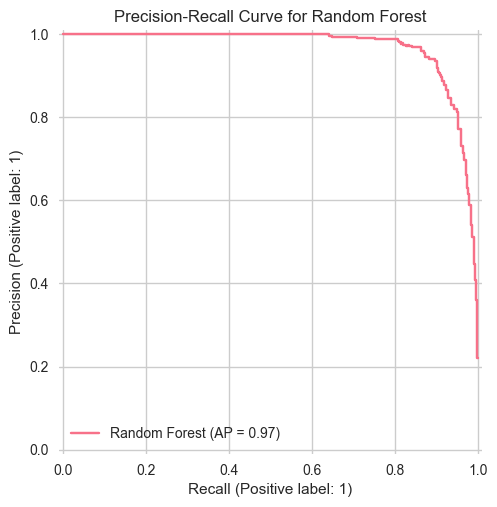

In [19]:
# --- Precision-Recall Curve ---
from sklearn.metrics import PrecisionRecallDisplay

# Get the best model
best_model = results['Random Forest']['model']

# Plot the curve
display = PrecisionRecallDisplay.from_estimator(
    best_model, X_test_scaled, y_test, name="Random Forest"
)
_ = display.ax_.set_title("Precision-Recall Curve for Random Forest")
plt.show()

# 5. AI Tooling Reflection

## AI Tools Used
- **Gemini:** Gemini 2.5 Pro has the largest context window so this was my primary LLM I used to understand the assignment and work through it. I often created new threads when context got overloaded. I input both the template, and my working notebook and used it to generate code and ask questions about concepts.
- **Gemini Embedded in Colab:** Used to understand code snippets in the template and data loading/cleaning.
- **Cursor:** I used Cursor less than I typically do for web development. However, it was useful for helping me generate additional visualizations once I had completed the notebook.

## Impact on Development
- **Speed:** Between loading, cleaning, visualization, training, testing, and my being curious, this project took me about 4 hours. If I did not have any AI tools I assume it would have taken me several days or a week maybe. Mostly because I am still familiarizing myself with the python libraries used, and the LLM had a good grasp on them already. So I was easily able to convert English language into python, debug quicker etc. Also, AI helped me understand concepts where I had quesitons almost instantly.
- **Learning:** Increased familiarity with python libraries, ability to ask ML questions.
- **Challenges:** Due to context window limitations, AI did not really understand the data structure. There are message limits in Gemini embedded in Colab as well, so I couldn't even give it all the column names in the data set. However this forced me to think more critically and manually read through the example python code to fit my specific dataset.

## Code Generated with AI
Almost all the code was either generated directly with AI or taken from the template notebook and adjusted with the assistance of AI.

# 6. Conclusions

## Key Findings
- The Random Forest model significantly outperformed the other models, achieving a validation accuracy of approximately 0.94 and a final test accuracy of 0.9491. This is likely because as an ensemble method, it can capture more complex and non-linear relationships within the transaction data compared to the linear nature of Logistic Regression or the boundary-based approach of SVM.
- The model's high performance, particularly its F1-score of 0.89 for the fraud class on the test set, indicates that there are strong, learnable patterns in the transactional features that distinguish fraudulent accounts from legitimate ones. This suggests that features related to transaction frequency, value, and interactions with ERC20 tokens are highly predictive.
- The Random Forest model showed signs of overfitting during training, achieving 100% accuracy on the training data. However, its strong performance on the validation and test sets shows that it still generalized very well to unseen data. This is a common characteristic of Random Forest but confirms its robustness for this particular dataset.

## Model Performance Summary
- **Best Model:** Random Forest Classifier with 95.68%% test accuracy. Notably, recall for legitimate addresses was 99%, and for fraud examples it was 83%. So the model is more likely to present a false negative than a false positive. This is useful to note if used in production, especially if UX is a high priority and there is low tolerance for flagging legitimate addresses as fraudulent. 
- **Key Factors:** The model's success is attributable to its ensemble nature, which combines many decision trees to make a more robust prediction. It effectively balanced precision and recall for the minority fraud class, resulting in a strong F1-score of 0.89.

## Limitations
- The dataset, while effective, is a static snapshot. Real-world fraud patterns evolve, so the model's performance could degrade over time without retraining. The dataset is also imbalanced, and while the model handled it well, more advanced techniques could be used to ensure the model isn't biased towards the non-fraudulent class.

- If this model was implemented at scale, attackers could proactively check their addresses and create fresh addresses to work around checks utilizing this (or similar) models. 

- The Random Forest model is considered more of a "black box" than a model like Logistic Regression. It is difficult to determine the exact reason a specific transaction was flagged as fraudulent, which can be a drawback in a production environment.


## Future Work
- Feature Engineering: Future work could involve creating new features, such as the ratio of sent to received ether, transaction timing patterns, or network-based features (e.g., how connected an address is to other known fraudulent accounts).


## Broader Implications
1. Crypto Exchanges, flagging withdrawals to fraudulent addresses. CEX exchange compromises are a significant issue in crypto. Many users don't enable address whitelisting, so this fraudulent address detection model could be used as a final check to reduce the odds of an attacker draining a CEX account. 
2. Wallet Software (e.g., MetaMask, Rabby, Coinbase Wallet). Wallet software often has features to prevent sending to wrong addresses. A check with this model or similar could add to the security of the wallet.